# Tech Challenge - Fase 1

## Desafio

Um grande hospital universitário busca implementar um sistema inteligente de suporte ao diagnóstico, capaz de ajudar médicos e equipes clínicas na análise inicial de exames e no processamento de dados médicos.

Com um volume crescente de pacientes e exames, como radiografias, tomografias, ressonâncias e prontuários digitalizados, o hospital precisa de soluções que acelerem a triagem e apoiem as decisões médicas, reduzindo erros e otimizando o tempo dos profissionais.

Nesta primeira fase, o desafio é criar a base do sistema de IA focado em machine learning, permitindo que resultados de exames sejam analisados automaticamente e destacando informações relevantes para o diagnóstico.

## Objetivo

Construir uma solução inicial com foco em IA para processamento de exames médicos e documentos clínicos, aplicando fundamentos essenciais de IA, Machine Learning e Visão Computacional.

## Patologia escolhida para o desafio: Acidente Vascular Cerebral (AVC)

### O que é o AVC

O Acidente Vascular Cerebral (AVC) é uma condição em que o fluxo de sangue para uma parte do cérebro é interrompido. Como as células cerebrais dependem de oxigênio e nutrientes trazidos pelo sangue, essa interrupção pode causar danos neurológicos em poucos minutos.

### Tipos de AVC

1. AVC Isquêmico

- Ocorre quando um vaso sanguíneo é bloqueado por um coágulo.
- É o tipo mais comum.
- Geralmente relacionado a aterosclerose, fibrilação atrial e fatores de risco cardiovasculares.

2. AVC Hemorrágico
- Acontece quando um vaso sanguíneo se rompe, causando sangramento no cérebro.
- Pode ser causado por hipertensão não controlada, aneurismas ou malformações vasculares.

### Base de Dados - NHANES (https://www.cdc.gov/nchs/nhanes)

O NHANES (National Health and Nutrition Examination Survey) é uma base de dados pública conduzida pelo CDC (Centers for Disease Control and Prevention) dos Estados Unidos, voltada à avaliação do estado de saúde e nutricional da população norte-americana.

De forma breve:

- Natureza: estudo observacional, transversal, com amostragem probabilística representativa da população dos EUA.

- Periodicidade: realizado continuamente, organizado em ciclos bienais (ex.: 2017–2018 https://wwwn.cdc.gov/Nchs/Nhanes/continuousnhanes/default.aspx?BeginYear=2017).

- Conteúdo: combina

    - Questionários (doenças autorreferidas, estilo de vida, tabagismo, diabetes, histórico de AVC),

    - Exames físicos (pressão arterial, IMC, medidas corporais),

    - Exames laboratoriais (glicemia, hemoglobina glicada, colesterol, triglicerídeos, marcadores inflamatórios).

- Formato dos dados: arquivos modulares (.XPT), integrados por um identificador único do participante (SEQN).

- Aspecto metodológico importante: inclui pesos amostrais e variáveis de desenho complexo, permitindo inferência populacional.

No contexto acadêmico, o NHANES é amplamente utilizado para modelagem de risco cardiovascular e de AVC, epidemiologia, análise de fatores de risco e aplicações de machine learning em saúde, sendo valorizado pela qualidade dos dados, transparência metodológica e acesso aberto.

**Importando a base de dados**

In [205]:
import pandas as pd  # importa a biblioteca pandas

pd.set_option('display.max_columns', None)  # configura o pandas para mostrar todas as colunas ao exibir DataFrames

import pandas as pd  # importa a biblioteca pandas

pd.set_option('display.max_columns', None)  # configura o pandas para mostrar todas as colunas ao exibir DataFrames

cycle_map = {
    "2005-2006": "_D",
    "2007-2008": "_E",
    "2009-2010": "_F",
    "2011-2012": "_G",
    "2013-2014": "_H",
    "2015-2016": "_I",
    "2017-2018": "_J"
}

modules = {  # dicionário que mapeia nomes lógicos para templates de arquivos XPT
    "demo": "DEMO{}.XPT",  # arquivo DEMO (dados demográficos): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DEMO_J.htm (ajustado para usar a letra do ciclo)
    "bpx": "BPX{}.XPT",     # arquivo BPX (medidas de pressão arterial): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPX_J.htm
    "bpq": "BPQ{}.XPT", # arquivo BPQ (pressão arterial e colesterol): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPQ_J.htm
    "ocq": "OCQ{}.XPT",     # arquivo OCQ (questionário de ocupação): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/OCQ_J.htm
    "ghb": "GHB{}.XPT",     # arquivo GHB (hemoglobina glicada): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/GHB_J.htm
    "bmx": "BMX{}.XPT",     # arquivo BMX (medidas corporais): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.htm
    "smq": "SMQ{}.XPT",     # arquivo SMQ (questionário de tabagismo): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/SMQ_J.htm
    "mcq": "MCQ{}.XPT"     # arquivo de questionário médico (histórico de doenças): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/MCQ_J.htm
}

dfs = {name: [] for name in modules}  # dicionário de listas para armazenar os DataFrames de cada módulo por ciclo

cycles = list(cycle_map.keys())  # lista de ciclos (ex.: ["2011-2012", "2017-2018"])

for cycle in cycles:
    letter = cycle_map[cycle]  # obtém a letra do ciclo (ex.: "G" para "2011-2012")
    year = cycle.split('-')[0]  # obtém o ano inicial do ciclo (ex.: "2011" para "2011-2012")
    base_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/" + year + "/DataFiles/"  # URL base para os arquivos NHANES, usando o ano inicial
    for name, file_template in modules.items():  # itera sobre (nome, template de arquivo) do dicionário modules
        file = file_template.format(letter)  # formata o template com a letra do ciclo (ex.: "DEMO_G.XPT")
        print(f"Carregando {file} para o ciclo {cycle}...")
        dfs[name].append(pd.read_sas(base_url + file))  # lê o arquivo XPT remoto e adiciona à lista de dfs[name]

# concatena os DataFrames de cada módulo de todos os ciclos
demo_df = pd.concat(dfs["demo"], ignore_index=True)
bpx_df = pd.concat(dfs["bpx"], ignore_index=True)
bpq_df = pd.concat(dfs["bpq"], ignore_index=True)
ocq_df = pd.concat(dfs["ocq"], ignore_index=True)
ghb_df = pd.concat(dfs["ghb"], ignore_index=True)
bmx_df = pd.concat(dfs["bmx"], ignore_index=True)
smq_df = pd.concat(dfs["smq"], ignore_index=True)
mcq_df = pd.concat(dfs["mcq"], ignore_index=True)

# inicia com o DataFrame 'demo' concatenado e faz merges left sucessivos com os outros DataFrames concatenados usando 'SEQN' como chave
df = demo_df \
    .merge(bpx_df, on="SEQN", how="left") \
    .merge(bpq_df, on="SEQN", how="left") \
    .merge(ocq_df, on="SEQN", how="left") \
    .merge(ghb_df, on="SEQN", how="left") \
    .merge(bmx_df, on="SEQN", how="left") \
    .merge(smq_df, on="SEQN", how="left") \
    .merge(mcq_df, on="SEQN", how="left")

df.head()  # exibe a forma (número de linhas e colunas) do DataFrame final combinado


Carregando DEMO_D.XPT para o ciclo 2005-2006...
Carregando BPX_D.XPT para o ciclo 2005-2006...
Carregando BPQ_D.XPT para o ciclo 2005-2006...
Carregando OCQ_D.XPT para o ciclo 2005-2006...
Carregando GHB_D.XPT para o ciclo 2005-2006...
Carregando BMX_D.XPT para o ciclo 2005-2006...
Carregando SMQ_D.XPT para o ciclo 2005-2006...
Carregando MCQ_D.XPT para o ciclo 2005-2006...
Carregando DEMO_E.XPT para o ciclo 2007-2008...
Carregando BPX_E.XPT para o ciclo 2007-2008...
Carregando BPQ_E.XPT para o ciclo 2007-2008...
Carregando OCQ_E.XPT para o ciclo 2007-2008...
Carregando GHB_E.XPT para o ciclo 2007-2008...
Carregando BMX_E.XPT para o ciclo 2007-2008...
Carregando SMQ_E.XPT para o ciclo 2007-2008...
Carregando MCQ_E.XPT para o ciclo 2007-2008...
Carregando DEMO_F.XPT para o ciclo 2009-2010...
Carregando BPX_F.XPT para o ciclo 2009-2010...
Carregando BPQ_F.XPT para o ciclo 2009-2010...
Carregando OCQ_F.XPT para o ciclo 2009-2010...
Carregando GHB_F.XPT para o ciclo 2009-2010...
Carregando

,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,DMQMILIT,DMDBORN,DMDCITZN,DMDYRSUS,DMDEDUC3,DMDEDUC2,DMDSCHOL,DMDMARTL,DMDHHSIZ,DMDFMSIZ,INDHHINC,INDFMINC,INDFMPIR,RIDEXPRG,DMDHRGND,DMDHRAGE,DMDHRBRN,DMDHREDU,DMDHRMAR,DMDHSEDU,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANG,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,DMDBORN2,INDHHIN2,INDFMIN2,DMDHRBR2,RIDRETH3,RIDEXAGY,RIDEXAGM,DMQMILIZ,DMQADFC,DMDBORN4,AIALANGA,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRBR4,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,PEASCST1,PEASCTM1,PEASCCT1,BPXCHR,BPQ150A,BPQ150B,BPQ150C,BPQ150D,BPAARM,BPACSZ,BPXPLS,BPXDB,BPXPULS,BPXPTY,BPXML1,BPXSY1,BPXDI1,BPAEN1,BPXSY2,BPXDI2,BPAEN2,BPXSY3,BPXDI3,BPAEN3,BPXSY4,BPXDI4,BPAEN4,BPQ020,BPQ030,BPQ040A,BPQ050A,BPQ060,BPQ070,BPQ080,BPQ090A,BPQ090B,BPQ090C,BPQ090D,BPQ100A,BPQ100B,BPQ100C,BPQ100D,BPD035,BPQ052,BPQ057,BPQ056,BPD058,BPQ059,OCD150,OCQ180,OCQ210,OCD231,OCD241,OCQ260,OCQ265,OCD270,OCQ290G,OCQ290Q,OCQ380,OCD390G,OCD392,OCD395,OCD391,OCQ510,OCQ520,OCQ530,OCQ540,OCQ550,OCQ560,OCQ570,OCQ580,OCQ275,OCQ600,OCQ610,OCQ630,OCQ640,OCQ660,OCQ670,LBXGH,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,BMXBMI,BMXLEG,BMILEG,BMXCALF,BMICALF,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXTHICR,BMITHICR,BMXTRI,BMITRI,BMXSUB,BMISUB,BMDBMIC,BMXSAD1,BMXSAD2,BMXSAD3,BMXSAD4,BMDAVSAD,BMDSADCM,BMXHIP,BMIHIP,SMQ020,SMD030,SMQ040,SMQ050Q,SMQ050U,SMD055,SMD057,SMD070,SMD075,SMQ077,SMD641,SMD650,SMD093,SMDUPCA,SMD100BR,SMD100FL,SMD100MN,SMD100LN,SMD100TR,SMD100NI,SMD100CO,SMQ620,SMD630,SMQ660,SMQ664M,SMQ664C,SMQ664W,SMQ664B,SMQ664O,SMQ666M,SMQ666C,SMQ666K,SMQ666W,SMQ666B,SMQ666S,SMQ666O,SMQ670,SMAQUEX2,SMQ621,SMQ078,SMQ661,SMQ665A,SMQ665B,SMQ665C,SMQ665D,SMQ848,SMQ852Q,SMQ852U,SMQ925,SMQ930,SMQ935,SMQ080,SMQ890,SMQ895,SMQ900,SMQ905,SMQ910,SMQ915,MCQ010,MCQ025,MCQ035,MCQ040,MCQ050,MCQ053,MCQ080,MCQ092,MCD093,MCQ140,MCQ149,MCQ150G,MCQ150Q,MCQ160A,MCQ160B,MCQ160C,MCQ160D,MCQ160E,MCQ160F,MCQ160G,MCQ160K,MCQ160L,MCQ160M,MCQ170K,MCQ170L,MCQ170M,MCQ180A,MCQ180B,MCQ180C,MCQ180D,MCQ180E,MCQ180F,MCQ180G,MCQ180K,MCQ180L,MCQ180M,MCQ190,MCQ220,MCQ230A,MCQ230B,MCQ230C,MCQ230D,MCQ240A,MCQ240B,MCQ240C,MCQ240D,MCQ240E,MCQ240F,MCQ240G,MCQ240H,MCQ240I,MCQ240J,MCQ240K,MCQ240L,MCQ240M,MCQ240N,MCQ240O,MCQ240P,MCQ240Q,MCQ240R,MCQ240S,MCQ240T,MCQ240U,MCQ240V,MCQ240W,MCQ240X,MCQ240Y,MCQ240Z,MCQ240AA,MCQ240BB,MCQ240CC,MCQ240DD,MCQ240DK,MCQ245A,MCQ245B,MCQ265,MCQ268A,MCQ268B,MCQ268C,MCQ268D,MCQ300A,MCQ300B,MCQ300C,MCQ310,MCQ320,MCD330,MCQ340,MCQ350,MCQ051,MCQ160N,MCQ180N,MCQ070,MCQ082,MCQ086,MCQ191,MCQ075,MCQ084,MCQ195,MCQ365A,MCQ365B,MCQ365C,MCQ365D,MCQ370A,MCQ370B,MCQ370C,MCQ370D,MCQ380,AGQ030,MCQ151,MCQ160O,MCQ203,MCQ206,OSQ230,RHD018,MCD180A,MCD180N,MCD180B,MCD180C,MCD180D,MCD180E,MCD180F,MCD180M,MCD180G,MCD180K,MCD180L,MCQ500,MCQ510A,MCQ510B,MCQ510C,MCQ510D,MCQ510E,MCQ510F,MCQ520,MCQ530,MCQ540,MCQ550,MCQ560,MCQ570,MCD240A,MCD240B,MCD240C,MCQ366A,MCQ366B,MCQ366C,MCQ366D,MCQ371A,MCQ371B,MCQ371C,MCQ371D
0,31127.0,4.0,2.0,2.0,1.0,5.397605e-79,11.0,12.0,3.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,4.0,4.0,4.0,4.0,0.75,NaN,2.0,21.0,1.0,3.0,1.0,2.0,1.0,1.0,2.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,6434.950248,6571.396373,2.0,44.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,41.0,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,10.2,NaN,73.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,NaN,15.5,NaN,NaN,NaN,NaN,NaN,12.8,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [206]:
df.shape

(70190, 383)

In [207]:
# manter somente as colunas solicitadas (se existirem) e avisar se alguma estiver ausente
cols_to_keep = [
    "SEQN", # Respondent sequence number
    "RIAGENDR", # Gender (DEMO): 1 - Male, 2 - Female
    "RIDAGEYR", # Age in years at screening (DEMO): 0 YEARS - 150 YEARS
    "BPQ020", # Ever told you had high blood pressure (BPQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
    "MCQ160B",  # Ever told had congestive heart failure (MCQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
    "DMDMARTL", # Marital status (DEMO): 1 - Married, 2 - Widowed, 3 - Divorced, 4 - Separated, 5 - Never married, 6 - Living with partner
    "OCQ260", # Description of job/work situation (OCQ): 1 - An employee of a private company, business, or individual for wages, salary, or commission., 2 - A federal government employee, 3 - A state government employee, 4 - A local government employee, 5 - Self-employed in own business, Working without pay in family business or farm, 6 - Refused, 77 - Don't know, 99 - Refused
    "BPXSY1", # Systolic blood pressure (BPX): 72 to 228 mm Hg
    "LBXGH", # Glycohemoglobin (GHB)
    "BMXBMI", # Body Mass Index (BMX)
    "SMQ020", # Ever smoked a cigar even 1 time? (SMQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
    "MCQ160F" # TARGET -> Ever told you had a stroke (MCQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
]

# verifica colunas ausentes
missing = [c for c in cols_to_keep if c not in df.columns]
if missing:
    print("Aviso: colunas ausentes e que não foram selecionadas:", missing)

# filtra o DataFrame para manter somente as colunas desejadas que existem
df = df[[c for c in cols_to_keep if c in df.columns]].copy()

# renomeia as colunas usando sufixos descritivos
suffix_descriptions = {
    "SEQN": "id", # Respondent sequence number
    "RIAGENDR": "gender", # Gender
    "RIDAGEYR": "age", # Age in years
    "BPQ020": "high_bp", # High blood pressure
    "MCQ160B": "chf", # Congestive heart failure
    "DMDMARTL": "marital", # Marital status
    "OCQ260": "occupation", # Occupation
    "BPXSY1": "sbp", # Systolic blood pressure
    "LBXGH": "hba1c", # Glycohemoglobin
    "BMXBMI": "bmi", # Body Mass Index
    "SMQ020": "smoking", # Smoking
    "MCQ160F": "stroke" # Ever told you had a stroke
}

# renomeia as colunas do DataFrame
rename_map = {c: f"{c}_{suffix_descriptions[c]}" for c in df.columns if c in suffix_descriptions}
df = df.rename(columns=rename_map)

print("Colunas renomeadas:", list(rename_map.values()))

df.shape

Colunas renomeadas: ['SEQN_id', 'RIAGENDR_gender', 'RIDAGEYR_age', 'BPQ020_high_bp', 'MCQ160B_chf', 'DMDMARTL_marital', 'OCQ260_occupation', 'BPXSY1_sbp', 'LBXGH_hba1c', 'BMXBMI_bmi', 'SMQ020_smoking', 'MCQ160F_stroke']


(70190, 12)

**Exploração de dados**

In [208]:
df.head(5)

,SEQN_id,RIAGENDR_gender,RIDAGEYR_age,BPQ020_high_bp,MCQ160B_chf,DMDMARTL_marital,OCQ260_occupation,BPXSY1_sbp,LBXGH_hba1c,BMXBMI_bmi,SMQ020_smoking,MCQ160F_stroke
0,31127.0,1.0,5.397605e-79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,31128.0,2.0,1.100000e+01,NaN,NaN,NaN,NaN,100.0,NaN,17.45,NaN,NaN
2,31129.0,1.0,1.500000e+01,NaN,NaN,5.0,NaN,104.0,5.2,26.53,NaN,NaN
3,31130.0,2.0,8.500000e+01,2.0,2.0,2.0,NaN,NaN,NaN,NaN,2.0,2.0
4,31131.0,2.0,4.400000e+01,1.0,1.0,1.0,1.0,144.0,6.0,30.90,2.0,2.0


In [209]:
# verificar as 20 colunas com mais valores ausentes
df.isnull().sum().sort_values(ascending=False).head(20)

OCQ260_occupation    46547
MCQ160B_chf          30442
MCQ160F_stroke       30442
SMQ020_smoking       29538
DMDMARTL_marital     28722
BPQ020_high_bp       25490
LBXGH_hba1c          25181
BPXSY1_sbp           21471
BMXBMI_bmi            8550
RIDAGEYR_age             0
SEQN_id                  0
RIAGENDR_gender          0
dtype: int64

In [210]:
# calcular o percentual de valores ausentes por coluna
total = len(df)

# exibir as 20 colunas com maior percentual de valores ausentes
(df.isnull().sum() / total * 100).sort_values(ascending=False).head(20)

OCQ260_occupation    66.315714
MCQ160B_chf          43.370851
MCQ160F_stroke       43.370851
SMQ020_smoking       42.082918
DMDMARTL_marital     40.920359
BPQ020_high_bp       36.315714
LBXGH_hba1c          35.875481
BPXSY1_sbp           30.589828
BMXBMI_bmi           12.181222
RIDAGEYR_age          0.000000
SEQN_id               0.000000
RIAGENDR_gender       0.000000
dtype: float64

<Axes: >

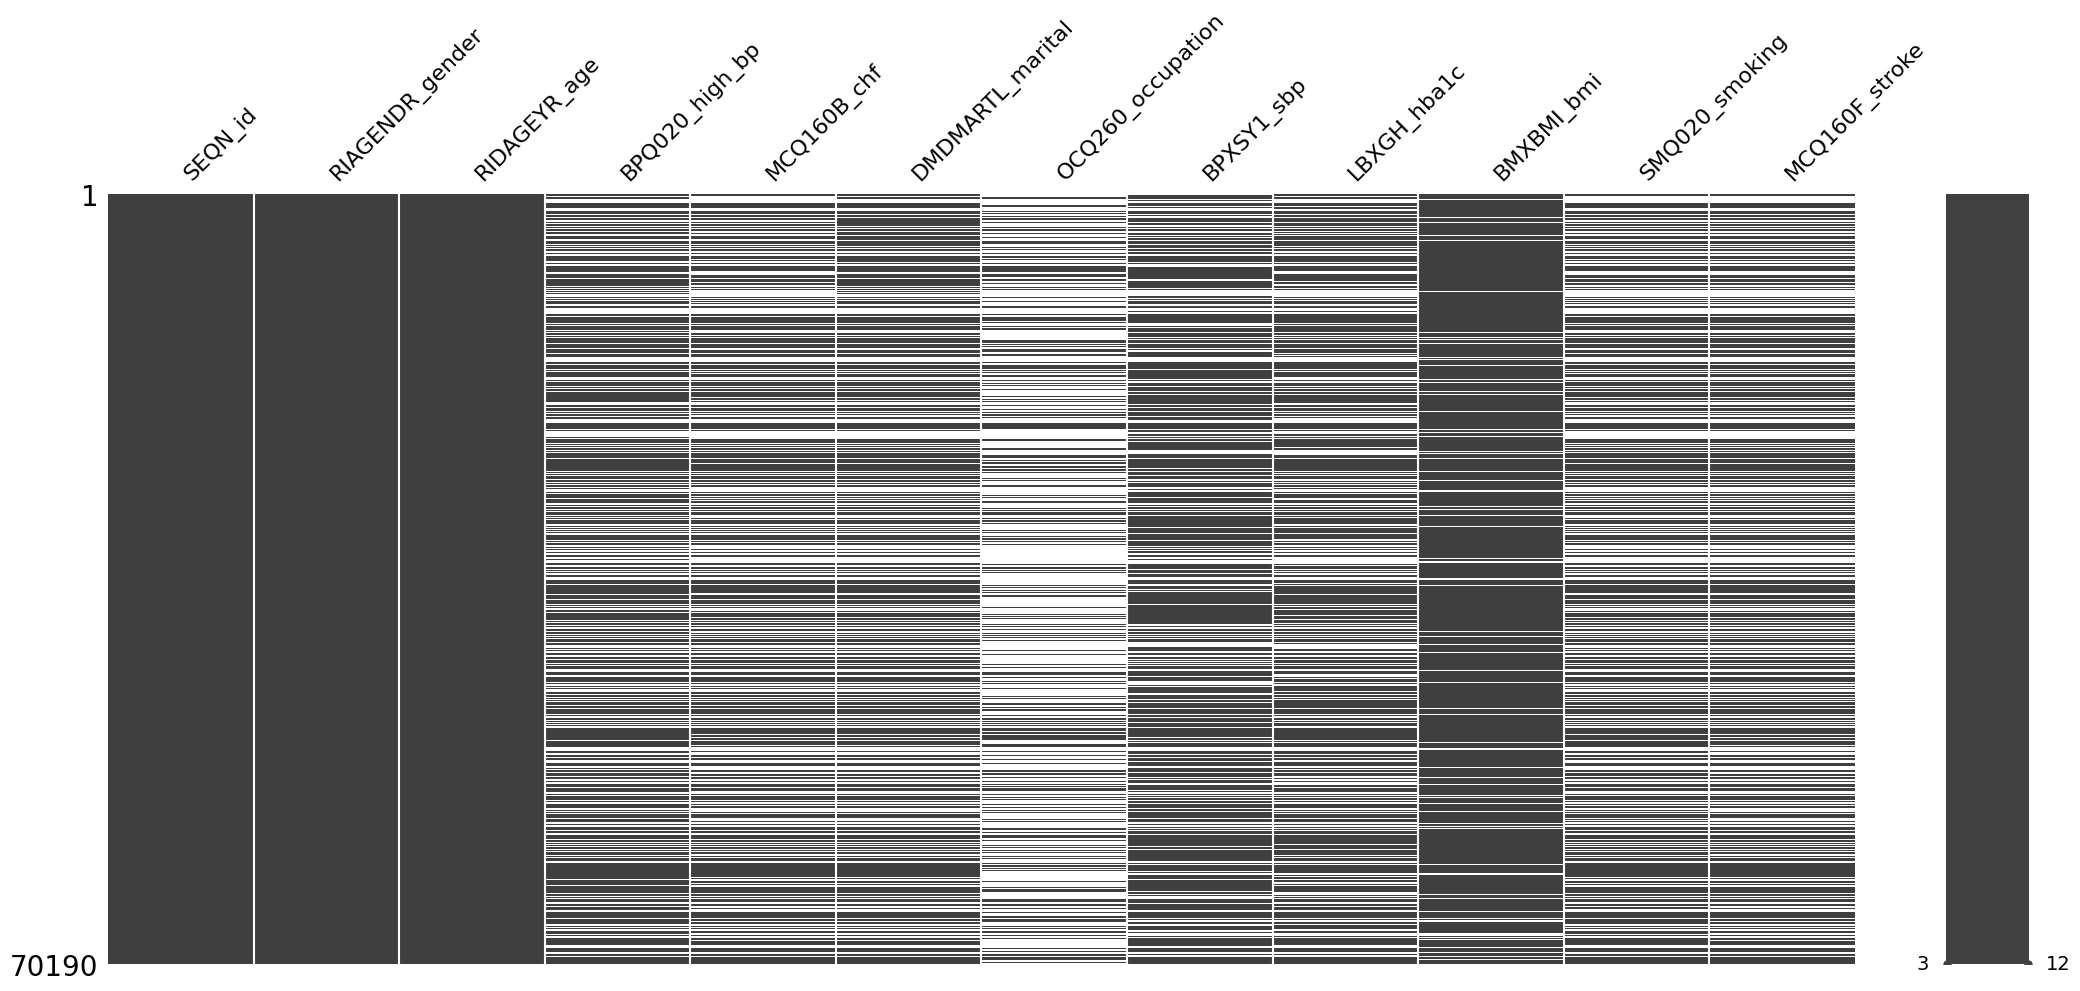

In [211]:
import missingno as msno

# visualizar os valores ausentes no DataFrame
msno.matrix(df)

<Axes: >

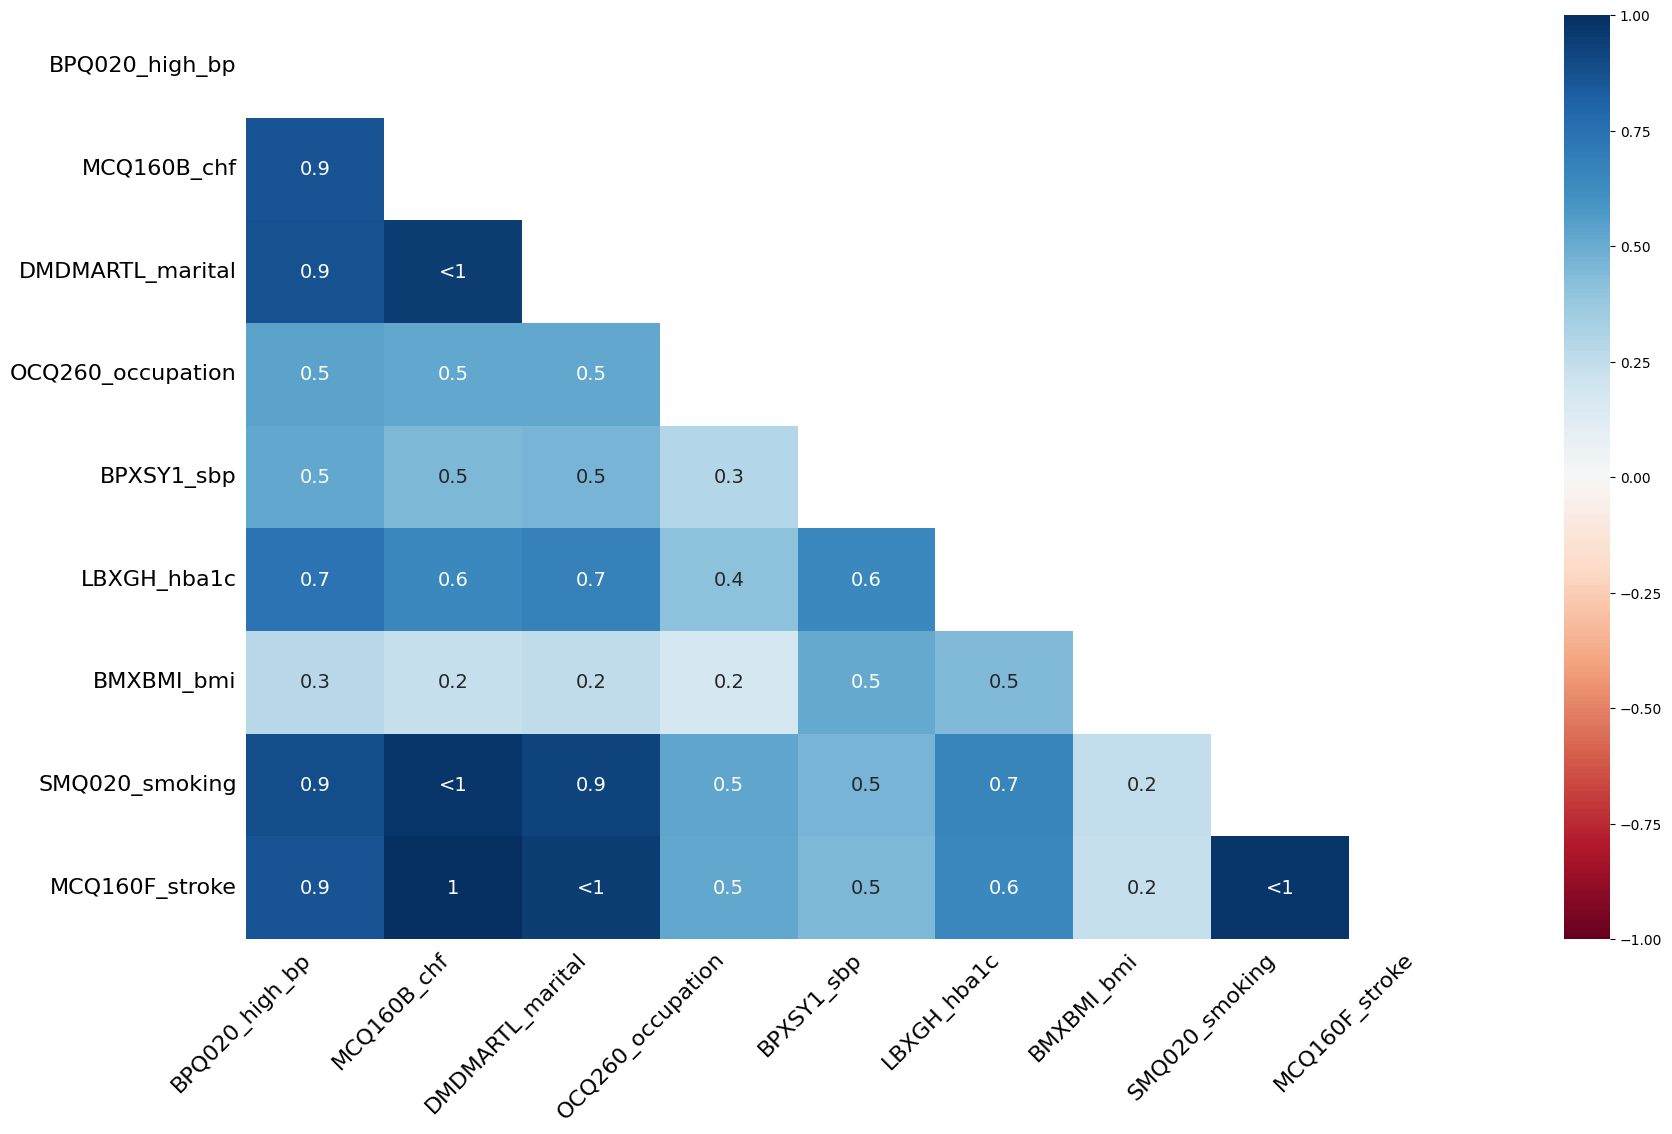

In [212]:
# visualizar o mapa de calor dos valores ausentes
msno.heatmap(df)

In [213]:
# exibir a forma inicial do DataFrame
print("Initial shape:", df.shape)

# Exibir missing por coluna
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Missing % per column:\n", missing_pct)

# Remover todas as linhas que possuem pelo menos um valor nulo
print('Shape antes do dropna:', df.shape)

# remover linhas com valores nulos
df = df.dropna()

print('Shape após remover todas as linhas com valores nulos:', df.shape)

# Verificar valores ambíguos nas variáveis categóricas e no alvo (códigos 7 e 9)
cat_cols = ['BPQ020_high_bp', 'MCQ160B_chf', 'SMQ020_smoking', 'MCQ160F_stroke']

# exibir contagens de valores para as colunas categóricas
rows_after = df.shape[0]

# exibir contagens de valores para as colunas categóricas
for c in cat_cols:
    if c in df.columns:
        print(c, "contagens de valor:")
        print(df[c].value_counts(dropna=False))

# Remover códigos ambíguos (7,9) das colunas categóricas e do alvo (se existirem)
amb_cols = [c for c in cat_cols if c in df.columns]
rows_before = df.shape[0]
for c in amb_cols:
    df = df[~df[c].isin([7,9])]
rows_after = df.shape[0]
print(f"Linhas removidas devido a códigos ambíguos. (7/9): {rows_before - rows_after}")

df.shape

Initial shape: (70190, 12)
Missing % per column:
 OCQ260_occupation    66.315714
MCQ160B_chf          43.370851
MCQ160F_stroke       43.370851
SMQ020_smoking       42.082918
DMDMARTL_marital     40.920359
BPQ020_high_bp       36.315714
LBXGH_hba1c          35.875481
BPXSY1_sbp           30.589828
BMXBMI_bmi           12.181222
RIDAGEYR_age          0.000000
SEQN_id               0.000000
RIAGENDR_gender       0.000000
dtype: float64
Shape antes do dropna: (70190, 12)
Shape após remover todas as linhas com valores nulos: (18501, 12)
BPQ020_high_bp contagens de valor:
BPQ020_high_bp
2.0    13854
1.0     4630
9.0       17
Name: count, dtype: int64
MCQ160B_chf contagens de valor:
MCQ160B_chf
2.0    18326
1.0      158
9.0       17
Name: count, dtype: int64
SMQ020_smoking contagens de valor:
SMQ020_smoking
2.0    10936
1.0     7557
9.0        8
Name: count, dtype: int64
MCQ160F_stroke contagens de valor:
MCQ160F_stroke
2.0    18303
1.0      189
9.0        9
Name: count, dtype: int64
Linhas r

(18453, 12)

In [214]:
df.head()

,SEQN_id,RIAGENDR_gender,RIDAGEYR_age,BPQ020_high_bp,MCQ160B_chf,DMDMARTL_marital,OCQ260_occupation,BPXSY1_sbp,LBXGH_hba1c,BMXBMI_bmi,SMQ020_smoking,MCQ160F_stroke
4,31131.0,2.0,44.0,1.0,1.0,1.0,1.0,144.0,6.0,30.90,2.0,2.0
5,31132.0,1.0,70.0,1.0,2.0,1.0,1.0,138.0,7.1,24.74,2.0,2.0
17,31144.0,1.0,21.0,2.0,2.0,5.0,2.0,116.0,4.8,25.03,2.0,2.0
27,31154.0,1.0,62.0,1.0,2.0,1.0,1.0,154.0,6.1,26.98,1.0,2.0
28,31155.0,1.0,38.0,2.0,2.0,1.0,3.0,126.0,4.9,25.61,2.0,2.0


In [215]:
# Verificar o DataFrame final
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18453 entries, 4 to 70186
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SEQN_id            18453 non-null  float64
 1   RIAGENDR_gender    18453 non-null  float64
 2   RIDAGEYR_age       18453 non-null  float64
 3   BPQ020_high_bp     18453 non-null  float64
 4   MCQ160B_chf        18453 non-null  float64
 5   DMDMARTL_marital   18453 non-null  float64
 6   OCQ260_occupation  18453 non-null  float64
 7   BPXSY1_sbp         18453 non-null  float64
 8   LBXGH_hba1c        18453 non-null  float64
 9   BMXBMI_bmi         18453 non-null  float64
 10  SMQ020_smoking     18453 non-null  float64
 11  MCQ160F_stroke     18453 non-null  float64
dtypes: float64(12)
memory usage: 1.8 MB


<Axes: >

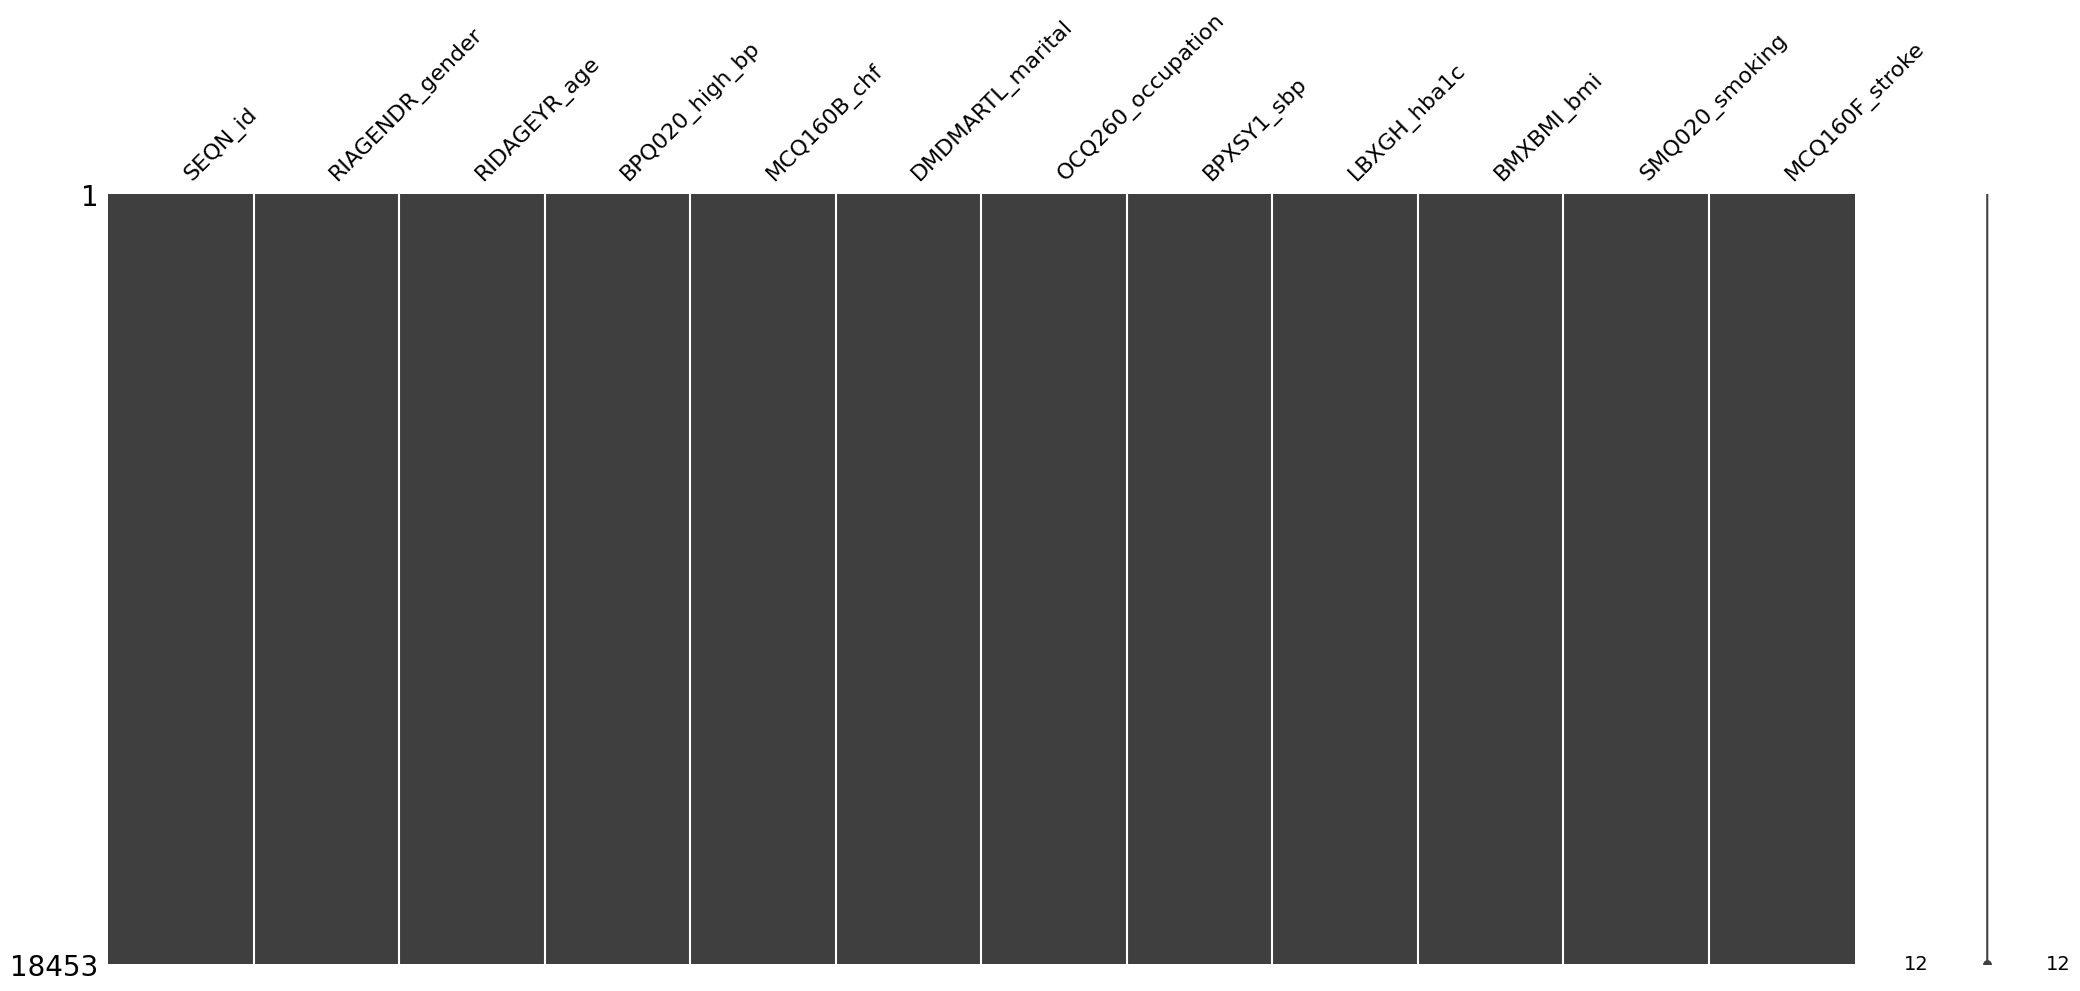

In [216]:
# visualizar o mapa de calor dos valores ausentes
msno.matrix(df)

In [217]:
# verificar os valores únicos da coluna alvo (original codes)
target_col = 'MCQ160F_stroke'

if target_col in df.columns:    print("Valores alvo unicos:", sorted(df[target_col].unique()))

Valores alvo unicos: [np.float64(1.0), np.float64(2.0)]


In [218]:
# Manter só 1 (Yes) e 2 (No) para as features categóricas
categorical_features = ['RIAGENDR_gender','BPQ020_high_bp', 'MCQ160B_chf', 'SMQ020_smoking']

for col in categorical_features:
    if col in df.columns:
        # Manter só 1 (Yes) e 2 (No)
        df = df[df[col].isin([1, 2])].copy()
        # Criar coluna binária
        binary_col = f"{col}_bin"
        df[binary_col] = df[col].map({1: 1, 2: 0})

        # Remove as colunas originais
        df = df.drop(columns=[col])

        print(f"\n{col}:")
        print(f"Counts (1=Yes, 0=No):")
        print(df[binary_col].value_counts())


# Criar coluna binária para DMDMARTL_marital
# 1 = já foi casado (1,2,3,4,6), 0 = nunca casou (5)
df['DMDMARTL_already_married'] = df['DMDMARTL_marital'].apply(
    lambda x: 1 if x in [1.0, 2.0, 3.0, 4.0, 6.0] else (0 if x == 5.0 else x)
)

df = df.drop('DMDMARTL_marital', axis=1)

print("\nDMDMARTL_marital -> DMDMARTL_already_married:")
print(f"Counts (1=already married, 0=never married):")
print(df['DMDMARTL_already_married'].value_counts())

df.head()


RIAGENDR_gender:
Counts (1=Yes, 0=No):
RIAGENDR_gender_bin
1    9870
0    8583
Name: count, dtype: int64

BPQ020_high_bp:
Counts (1=Yes, 0=No):
BPQ020_high_bp_bin
0    13837
1     4616
Name: count, dtype: int64

MCQ160B_chf:
Counts (1=Yes, 0=No):
MCQ160B_chf_bin
0    18295
1      158
Name: count, dtype: int64

SMQ020_smoking:
Counts (1=Yes, 0=No):
SMQ020_smoking_bin
0    10921
1     7532
Name: count, dtype: int64

DMDMARTL_marital -> DMDMARTL_already_married:
Counts (1=already married, 0=never married):
DMDMARTL_already_married
1.0     14672
0.0      3775
77.0        5
99.0        1
Name: count, dtype: int64


,SEQN_id,RIDAGEYR_age,OCQ260_occupation,BPXSY1_sbp,LBXGH_hba1c,BMXBMI_bmi,MCQ160F_stroke,RIAGENDR_gender_bin,BPQ020_high_bp_bin,MCQ160B_chf_bin,SMQ020_smoking_bin,DMDMARTL_already_married
4,31131.0,44.0,1.0,144.0,6.0,30.90,2.0,0,1,1,0,1.0
5,31132.0,70.0,1.0,138.0,7.1,24.74,2.0,1,1,0,0,1.0
17,31144.0,21.0,2.0,116.0,4.8,25.03,2.0,1,0,0,0,0.0
27,31154.0,62.0,1.0,154.0,6.1,26.98,2.0,1,1,0,1,1.0
28,31155.0,38.0,3.0,126.0,4.9,25.61,2.0,1,0,0,0,1.0


In [219]:
# Manter só 1 (Yes) e 2 (No) no alvo e criar coluna binária 'MCQ160F_stroke_bin'
target_col = 'MCQ160F_stroke'
if target_col in df.columns:
    df = df[df[target_col].isin([1,2])].copy()
    df['MCQ160F_stroke_bin'] = df[target_col].map({1:1, 2:0})
    print("Counts (1=stroke,0=no):")
    print(df['MCQ160F_stroke_bin'].value_counts())
    
    # Remove a coluna original
    df = df.drop(columns=[target_col])


Counts (1=stroke,0=no):
MCQ160F_stroke_bin
0    18265
1      188
Name: count, dtype: int64


In [220]:
# Resumo estatístico das colunas numéricas
df.describe()

,SEQN_id,RIDAGEYR_age,OCQ260_occupation,BPXSY1_sbp,LBXGH_hba1c,BMXBMI_bmi,RIAGENDR_gender_bin,BPQ020_high_bp_bin,MCQ160B_chf_bin,SMQ020_smoking_bin,DMDMARTL_already_married,MCQ160F_stroke_bin
count,18453.000000,18453.000000,18453.000000,18453.000000,18453.000000,18453.000000,18453.000000,18453.000000,18453.000000,18453.000000,18453.00000,18453.000000
mean,67920.669810,42.992251,2.265865,121.374411,5.627394,28.961313,0.534872,0.250149,0.008562,0.408172,0.82133,0.010188
std,20666.038099,14.099158,6.975281,16.305083,0.994004,6.652339,0.498796,0.433110,0.092138,0.491509,1.50276,0.100423
min,31131.000000,20.000000,1.000000,74.000000,2.000000,14.100000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,50135.000000,31.000000,1.000000,110.000000,5.200000,24.300000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000
50%,67591.000000,42.000000,1.000000,120.000000,5.400000,27.850000,1.000000,0.000000,0.000000,0.000000,1.00000,0.000000
75%,86150.000000,54.000000,2.000000,130.000000,5.700000,32.300000,1.000000,1.000000,0.000000,1.000000,1.00000,0.000000
max,102953.000000,85.000000,99.000000,238.000000,16.500000,84.870000,1.000000,1.000000,1.000000,1.000000,99.00000,1.000000


**Analisando as variáveis numéricas**

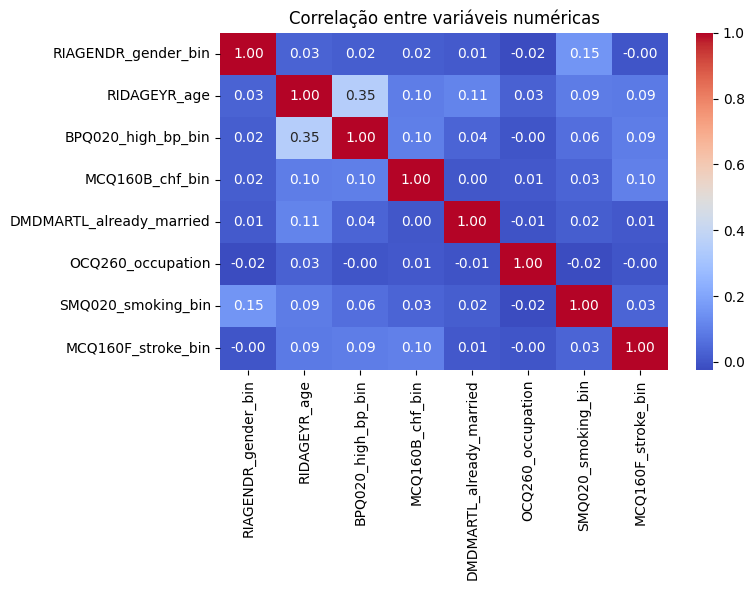

In [221]:
import matplotlib.pyplot as plt
import seaborn as sb

# 1) Heatmap de correlação (numéricas)
num_cols = ['RIAGENDR_gender_bin', 'RIDAGEYR_age', 'BPQ020_high_bp_bin', 'MCQ160B_chf_bin', 'DMDMARTL_already_married', 'OCQ260_occupation', 'SMQ020_smoking_bin', 'MCQ160F_stroke_bin']
# Keep only numeric columns for correlation (convert categories to numeric if needed)
corr_df = df[num_cols].copy()
corr_df = corr_df.apply(pd.to_numeric, errors='coerce')
plt.figure(figsize=(8,6))
sb.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre variáveis numéricas')
plt.tight_layout()

plt.show()


/tmp/ipykernel_30861/3209269551.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rate = df.groupby('age_bin')['MCQ160F_stroke_bin'].mean().reset_index()
/tmp/ipykernel_30861/3209269551.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='age_bin', y='MCQ160F_stroke_bin', data=age_rate, palette='viridis')


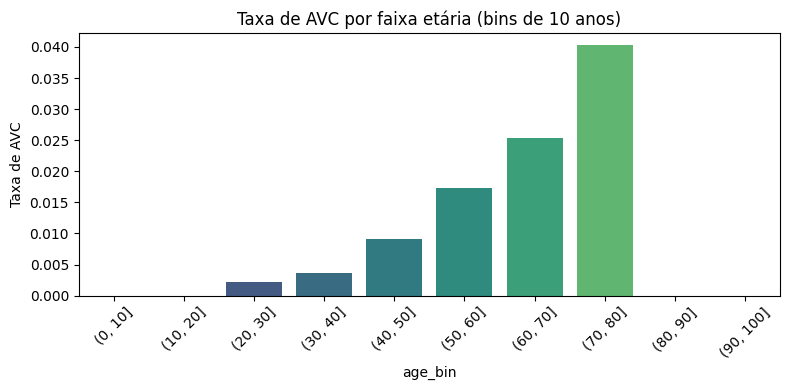

In [222]:
# Taxa de AVC por faixa etária
df['age_bin'] = pd.cut(df['RIDAGEYR_age'], bins=range(0, 101, 10))
age_rate = df.groupby('age_bin')['MCQ160F_stroke_bin'].mean().reset_index()
plt.figure(figsize=(8,4))
sb.barplot(x='age_bin', y='MCQ160F_stroke_bin', data=age_rate, palette='viridis')
plt.xticks(rotation=45)
plt.ylabel('Taxa de AVC')
plt.title('Taxa de AVC por faixa etária (bins de 10 anos)')
plt.tight_layout()
plt.show()

In [223]:
# Taxa de AVC por variáveis categóricas (BPQ020_high_bp, MCQ160B_chf, SMQ020_smoking)
label_map = {1: 'Sim', 2: 'Não'}
for var in ['BPQ020_high_bp', 'MCQ160B_chf', 'SMQ020_smoking']:
    if var in df.columns:
        agg = df.groupby(var)['MCQ160F_stroke_bin'].agg(['count','sum']).reset_index()
        agg['rate'] = agg['sum'] / agg['count']
        plt.figure(figsize=(5,3))
        sb.barplot(x=var, y='rate', data=agg, palette='coolwarm')
        plt.xticks(ticks=range(len(agg[var])), labels=[label_map.get(int(v), v) for v in agg[var]])
        plt.ylim(0, agg['rate'].max()*1.15)
        plt.ylabel('Taxa de AVC')
        plt.title(f'Taxa de AVC por {var}')
        plt.tight_layout()
        plt.show()

===== LogisticRegression =====
              precision    recall  f1-score   support

           0       1.00      0.74      0.85      3653
           1       0.03      0.74      0.06        38

    accuracy                           0.74      3691
   macro avg       0.51      0.74      0.45      3691
weighted avg       0.99      0.74      0.84      3691

ROC AUC: 0.7867290042791073
PR AUC: 0.036819188531603673
Confusion matrix:
 [[2719  934]
 [  10   28]]
===== RandomForest =====
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3653
           1       0.00      0.00      0.00        38

    accuracy                           0.99      3691
   macro avg       0.49      0.50      0.50      3691
weighted avg       0.98      0.99      0.98      3691

ROC AUC: 0.647395075424669
PR AUC: 0.02546569041676816
Confusion matrix:
 [[3653    0]
 [  38    0]]


/home/paulo/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/01-welcome-to-ia-para-devs/07-tech-challenge/venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/paulo/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/01-welcome-to-ia-para-devs/07-tech-challenge/venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/paulo/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/01-welcome-to-ia-para-devs/07-tech-challenge/venv/lib64/p


As 10 principais características por importância de permutação (RandomForest, características transformadas):
                               feature  importance       std
0                    num__RIDAGEYR_age    0.061088  0.028408
1                      num__BPXSY1_sbp    0.007738  0.031330
15         cat__SMQ020_smoking_bin_1.0    0.007076  0.016873
14         cat__SMQ020_smoking_bin_0.0    0.003970  0.017591
13            cat__MCQ160B_chf_bin_1.0    0.001103  0.005285
8   cat__DMDMARTL_already_married_77.0    0.000000  0.000000
9   cat__DMDMARTL_already_married_99.0    0.000000  0.000000
12            cat__MCQ160B_chf_bin_0.0   -0.000099  0.005446
11         cat__BPQ020_high_bp_bin_1.0   -0.005590  0.010824
7    cat__DMDMARTL_already_married_1.0   -0.005903  0.014466


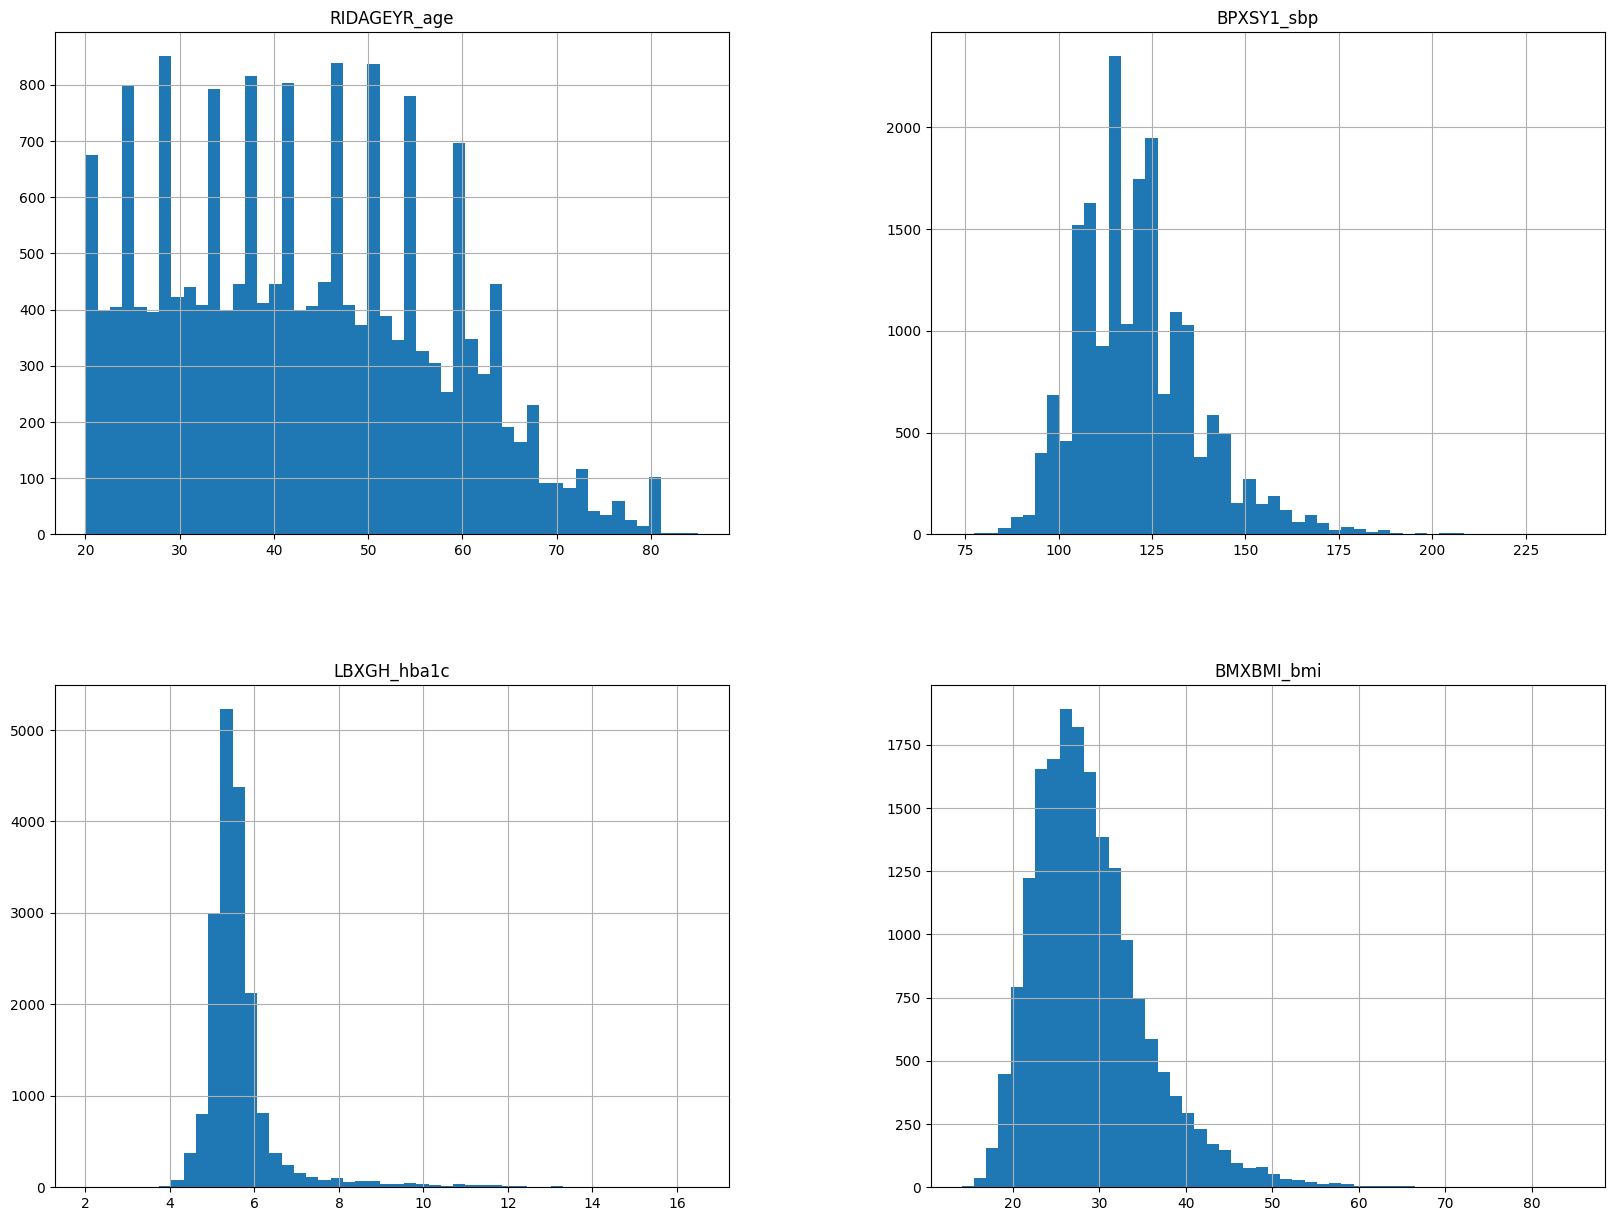

In [224]:
# Distribuição das variáveis numéricas (selecionadas)
num_hist_cols = ['RIDAGEYR_age', 'BPXSY1_sbp', 'LBXGH_hba1c', 'BMXBMI_bmi']
df[num_hist_cols].hist(bins=50, figsize=(20,15))

# Ajustar layout e mostrar os histogramas
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix

num_cols = ['RIDAGEYR_age', 'BPXSY1_sbp', 'LBXGH_hba1c', 'BMXBMI_bmi']
cat_cols = ['RIAGENDR_gender_bin', 'DMDMARTL_already_married', 'BPQ020_high_bp_bin', 'MCQ160B_chf_bin', 'SMQ020_smoking_bin']

# Eliminar linhas com alvo ausente
df_model = df.dropna(subset=['MCQ160F_stroke_bin']).copy()
X = df_model[num_cols + cat_cols]
y = df_model['MCQ160F_stroke_bin']

# Dividir em treino e teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Pipeline de pré-processamento
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))])

# Combinar pipelines numéricos e categóricos
preproc = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

pipe_lr = Pipeline([('pre', preproc), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))])
pipe_rf = Pipeline([('pre', preproc), ('clf', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42))])

# Treinar os modelos
pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

# Avaliar os modelos no conjunto de teste
for name, model in [('LogisticRegression', pipe_lr), ('RandomForest', pipe_rf)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred))
    print('ROC AUC:', roc_auc_score(y_test, y_prob))
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    print('PR AUC:', auc(recall, precision))
    print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))

# Importância da permutação (alternativa ao SHAP)
from sklearn.inspection import permutation_importance

# Calcular a importância da permutação nas características transformadas (após o pré-processamento).
X_test_trans = preproc.transform(X_test)
r = permutation_importance(pipe_rf.named_steps['clf'], X_test_trans, y_test, n_repeats=30, random_state=42, scoring='roc_auc')
feat_names = preproc.get_feature_names_out()

# Criar DataFrame de importâncias
imp_df = pd.DataFrame({'feature': feat_names, 'importance': r.importances_mean, 'std': r.importances_std})
imp_df = imp_df.sort_values('importance', ascending=False)

print('\nAs 10 principais características por importância de permutação (RandomForest, características transformadas):')
print(imp_df.head(10))

In [225]:
# Rebalanceamento por undersampling da classe majoritária
from sklearn.utils import resample

# Separar as classes
df_major = df_model[df_model['MCQ160F_stroke_bin'] == 0]
df_minor = df_model[df_model['MCQ160F_stroke_bin'] == 1]

# Reduzir classe majoritária para o tamanho da minoritária
df_major_down = resample(df_major, 
                         replace=True, 
                         n_samples=len(df_minor), 
                         random_state=42)

# Concatenar e embaralhar
df_balanced = pd.concat([df_major_down, df_minor]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribuição após undersampling:")
print(df_balanced['MCQ160F_stroke_bin'].value_counts())

# Redefinir X e y
X_bal = df_balanced[num_cols + cat_cols]
y_bal = df_balanced['MCQ160F_stroke_bin']

# Dividir em treino e teste
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(X_bal, y_bal, stratify=y_bal, test_size=0.2, random_state=42)

# Treinar e avaliar ambos os modelos com base balanceada
for name, model in [('LogisticRegression', pipe_lr), ('RandomForest', pipe_rf)]:
    model.fit(X_train_bal, y_train_bal)
    y_pred_bal = model.predict(X_test_bal)
    y_prob_bal = model.predict_proba(X_test_bal)[:,1]
    
    print(f"===== {name} (base balanceada) =====")
    print(classification_report(y_test_bal, y_pred_bal))
    print('ROC AUC:', roc_auc_score(y_test_bal, y_prob_bal))
    precision, recall, _ = precision_recall_curve(y_test_bal, y_prob_bal)
    print('PR AUC:', auc(recall, precision))
    print('Confusion matrix:\n', confusion_matrix(y_test_bal, y_pred_bal))
    print()

Distribuição após undersampling:
MCQ160F_stroke_bin
1    188
0    188
Name: count, dtype: int64
===== LogisticRegression (base balanceada) =====
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        38
           1       0.82      0.84      0.83        38

    accuracy                           0.83        76
   macro avg       0.83      0.83      0.83        76
weighted avg       0.83      0.83      0.83        76

ROC AUC: 0.9058171745152355
PR AUC: 0.8944147047404869
Confusion matrix:
 [[31  7]
 [ 6 32]]

===== RandomForest (base balanceada) =====
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        38
           1       0.79      0.82      0.81        38

    accuracy                           0.80        76
   macro avg       0.80      0.80      0.80        76
weighted avg       0.80      0.80      0.80        76

ROC AUC: 0.8874653739612188
PR AUC: 0.8852303563202265
Confusion

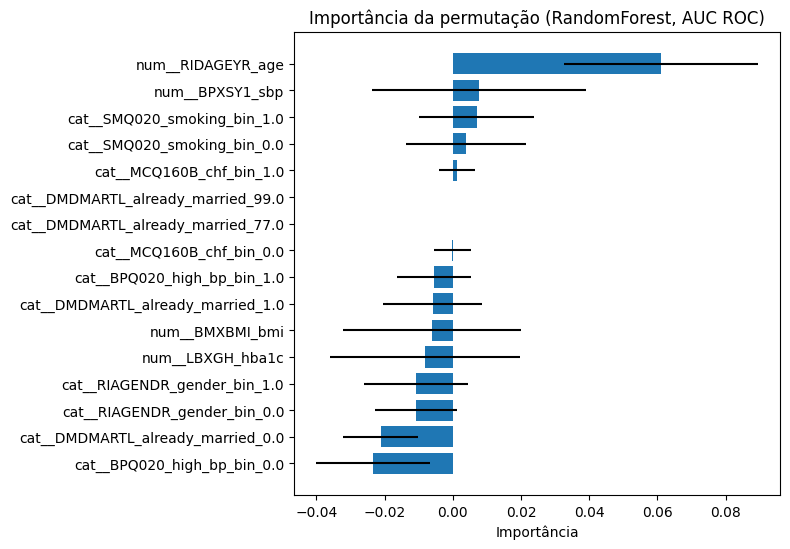

In [226]:
# Plote as principais permutações de importância (selecione as 20 principais para melhor visualização).
top_k = min(20, len(imp_df))

# Ordene o gráfico de barras horizontais em ordem crescente (com os elementos mais importantes no topo).
top = imp_df.head(top_k).sort_values('importance', ascending=True)
plt.figure(figsize=(8, max(4, 0.35*top_k)))
plt.barh(top['feature'], top['importance'], xerr=top['std'], color='C0')
plt.xlabel('Importância')
plt.title('Importância da permutação (RandomForest, AUC ROC)')
plt.tight_layout()
plt.show()

In [227]:
import pickle

# Salvar o modelo RandomForest treinado com base balanceada
with open('pipe_rf_model.pkl', 'wb') as f:
    pickle.dump(pipe_rf, f)

# Escolha dois registros aleatorios da base de teste balanceada (um com AVC e outro sem AVC) para teste do modelo salvo
test_samples = pd.concat([
    X_test_bal[y_test_bal == 1].sample(n=1, random_state=42),
    X_test_bal[y_test_bal == 0].sample(n=1, random_state=42)
])

# Adicionar coluna indicando se é stroke ou não
test_samples['MCQ160F_stroke_bin'] = y_test_bal.loc[test_samples.index]
test_samples['stroke_label'] = test_samples['MCQ160F_stroke_bin'].map({1: 'Stroke (Sim)', 0: 'No Stroke (Não)'})

test_samples.head(2)

,RIDAGEYR_age,BPXSY1_sbp,LBXGH_hba1c,BMXBMI_bmi,RIAGENDR_gender_bin,DMDMARTL_already_married,BPQ020_high_bp_bin,MCQ160B_chf_bin,SMQ020_smoking_bin,MCQ160F_stroke_bin,stroke_label
324,42.0,142.0,5.9,39.1,0,1.0,1,0,1,1,Stroke (Sim)
115,67.0,128.0,9.2,32.0,1,1.0,1,0,1,0,No Stroke (Não)


## Referências

- https://pandascouple.medium.com/projeto-machine-learning-previs%C3%A3o-de-avc-f4b7dce11929
- https://jornal.usp.br/radio-usp/uso-de-ia-e-analise-de-dados-na-prevencao-de-avc-e-ataque-isquemico-transitorio/
- https://www.nature.com/articles/s41598-024-61665-4?error=cookies_not_supported&code=1d85f26e-6ade-4ec5-9132-5511aa615597&_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc
- https://jhi.sbis.org.br/index.php/jhi-sbis/article/view/980
- https://www.nature.com/articles/s41598-025-01855-w
